In [1]:
import matplotlib.pyplot as plt
import scipy
import numpy as np
from model.parameters import *
from modules.transitory_functions import *
from scipy.integrate import BDF

In [2]:
Psat = Psat(323.15)

Anode control mode: pressure control at 1.35bar

In [3]:
Pasm = 1.35e5 #Pa
phi_a_asm = 0

Cathode control mode: flow control based on $S_c$

In [4]:
Sc = 1.2
i_fc = 0.8e4
Phi_hum = 1
# Molar mass of the humidified air
Mcp = Phi_hum * Psat / Pext * M_H2O + yO2_ext * (1 - Phi_hum * Psat / Pext) * M_O2 + (1 - yO2_ext) * (1 - Phi_hum * Psat / Pext) * M_N2
Win = n_cell*Mcp*(Pext/(Pext-Phi_hum*Psat)) * (1/yO2_ext) * Sc * i_fc * Aact / (4 * F)

In [5]:
Win_iload = []
Win_O2 = []
Win_N2 = []

for i_fc in np.arange(0,2,0.1):
    
    Win_iload.append((Pext/(Pext-Phi_hum*Psat)) * (1/yO2_ext) * Sc * i_fc * Aact / (4 * F * Hgc * Wgc))
    Win_O2.append(Sc * i_fc * Aact / (4 * F * Hgc * Wgc))
    Win_N2.append(((1 - yO2_ext)/(yO2_ext)) * Sc * i_fc * Aact / (4 * F * Hgc * Wgc))

Text(0, 0.5, '$mol/s$')

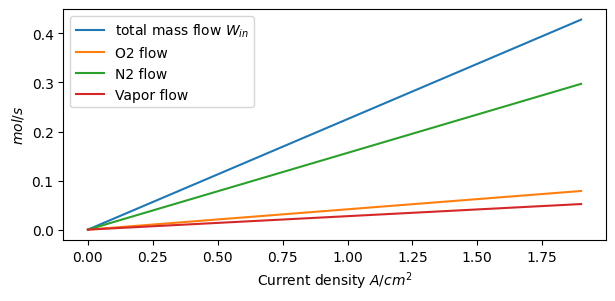

In [6]:
plt.figure(figsize=(7,3))
plt.plot(np.arange(0,2,0.1),Win_iload, label = r"total mass flow $W_{in}$")
plt.plot(np.arange(0,2,0.1),Win_O2, label = "O2 flow")
plt.plot(np.arange(0,2,0.1),Win_N2, label = "N2 flow")
plt.plot(np.arange(0,2,0.1),np.array(Win_iload) - np.array(Win_O2) - np.array(Win_N2), label = "Vapor flow")
plt.legend()
plt.xlabel(r"Current density $A/cm^2$")
plt.ylabel(r"$mol/s$")

In [7]:
def dxdt(t,x):
    """
    C_O2_cgc = x[0]
    C_N2 = [1]
    C_vp_cgc = x[2]
    :param t: 
    :param x: 
    :return: 
    """
    
    dxdt = [0,0,0]

    Pcgc = (x[0] + x[1] + x[2]) * 8.314 * 323.15
    Phi_cgc = x[2] / C_v_sat(323.15)
    yO2_cgc = x[0] / (x[0] + x[1])
    Mcgc = Phi_cgc * Psat / Pcgc * M_H2O + yO2_cgc * (1 - Phi_cgc * Psat / Pcgc) * M_O2 + (1 - yO2_cgc) * (1 - Phi_cgc * Psat / Pcgc) * M_N2

    Win_O2 = Sc * i_fc * Aact / (4 * F * Hgc * Wgc)
    Win_N2 = ((1 - yO2_ext)/(yO2_ext)) * Sc * i_fc * Aact / (4 * F * Hgc * Wgc)
    Win_vp = (Phi_hum*Psat/(Pext-Phi_hum*Psat)) * (1/yO2_ext) * Sc * i_fc * Aact / (4 * F * Hgc * Wgc)

    Wout = Kem_in * (Pcgc - 1e5) / (Hgc * Wgc * Mcgc)
    Wout_O2 = yO2_ext * ((Pcgc - Phi_cgc * Psat) / Pcgc) * Wout
    Wout_N2 = (1 - yO2_ext) * ((Pcgc - Phi_cgc * Psat) / Pcgc) * Wout
    Wout_vp = Phi_cgc * Psat / Pcgc * Wout

    dxdt[0] = (Win_O2 - Wout_O2) / Lgc
    dxdt[1] = (Win_N2 - Wout_N2) / Lgc
    dxdt[2] = (Win_vp - Wout_vp) / Lgc

    return dxdt

In [8]:
# O2, N2, Vapor
state0 = [4, 15, 1]
x_hist = []

solver = BDF(fun = dxdt, y0=state0,max_step=1, t0=0, t_bound=100)
while solver.status == "running":

    solver.step()
    x_hist.append(solver.y)
x_hist = np.array(x_hist)

Text(0, 0.5, '$mol/cm^3$')

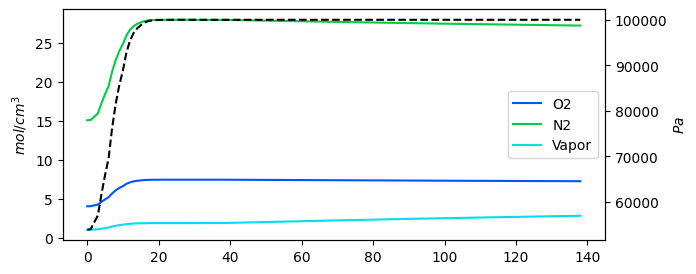

In [10]:
fig, ax = plt.subplots(figsize=(7,3))
colors = ["#0055ff","#00cc44","#00ddee"]
labels = ["O2", "N2", "Vapor"]
for i_x in range(3):
    ax.plot(x_hist[:,i_x],color=colors[i_x],label=labels[i_x])
ax_twi = ax.twinx()
ax_twi.plot((x_hist[:,0]+x_hist[:,1]+x_hist[:,2])*R*323.15, color="black",linestyle="dashed")
ax_twi.set_ylabel(r"$Pa$")
ax.legend(loc="best")
ax.set_ylabel(r"$mol/cm^3$")